# 📊 Análisis Exploratorio — `global_crisis_data_cleaned.csv`

Este notebook realiza un análisis estadístico completo del dataset de crisis financieras globales, incluyendo:

1. Carga y vista general del dataset
2. Estadísticas descriptivas
3. Análisis de sesgo (skewness) y curtosis
4. Boxplots por variable numérica
5. Distribución de variables binarias
6. Correlaciones
7. Detección de outliers (IQR)
8. Resumen final

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Estilo visual ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

PALETTE_NUM  = '#4C72B0'   # azul principal
PALETTE_WARN = '#DD8452'   # naranja para alertas
PALETTE_OK   = '#55A868'   # verde para normal

---
## 1. Carga y vista general

In [24]:
df = pd.read_csv('https://raw.githubusercontent.com/EtienneDefranc/FinancialCrisis-Predictor/refs/heads/master/global_crisis_data_cleaned.csv')

print(f'Filas   : {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()
print('Tipos de datos:')
print(df.dtypes)
print()
print('Valores nulos por columna:')
print(df.isnull().sum())

Filas   : 3,864
Columnas: 13

Tipos de datos:
iso3                        object
year                       float64
crisis_next_12m            float64
banking_crisis_next_12m    float64
debt_crisis_next_12m       float64
crisis_any                   int64
banking_crisis               int64
currency_crisis              int64
debt_crisis                  int64
inflation                  float64
gdp_growth                 float64
unemployment               float64
real_interest_rate_10y     float64
dtype: object

Valores nulos por columna:
iso3                       0
year                       0
crisis_next_12m            0
banking_crisis_next_12m    0
debt_crisis_next_12m       0
crisis_any                 0
banking_crisis             0
currency_crisis            0
debt_crisis                0
inflation                  0
gdp_growth                 0
unemployment               0
real_interest_rate_10y     0
dtype: int64


In [25]:
df.head()

,iso3,year,crisis_next_12m,banking_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,real_interest_rate_10y
0,AGO,1960.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
1,AGO,1961.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
2,AGO,1962.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
3,AGO,1963.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
4,AGO,1964.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689


In [26]:
# Separar variables numéricas continuas de las binarias/indicadoras
CONTINUOUS_COLS = ['inflation', 'gdp_growth', 'unemployment', 'real_interest_rate_10y']

BINARY_COLS = [
    'crisis_any', 'banking_crisis', 'currency_crisis', 'debt_crisis',
    'crisis_next_12m', 'banking_crisis_next_12m', 'debt_crisis_next_12m'
]

print('Variables continuas:', CONTINUOUS_COLS)
print('Variables binarias :', BINARY_COLS)

Variables continuas: ['inflation', 'gdp_growth', 'unemployment', 'real_interest_rate_10y']
Variables binarias : ['crisis_any', 'banking_crisis', 'currency_crisis', 'debt_crisis', 'crisis_next_12m', 'banking_crisis_next_12m', 'debt_crisis_next_12m']


---
## 2. Estadísticas descriptivas

In [27]:
desc = df[CONTINUOUS_COLS].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).T
desc['range']    = desc['max'] - desc['min']
desc['cv']       = (desc['std'] / desc['mean']).abs()   # Coeficiente de variación
desc['skewness'] = df[CONTINUOUS_COLS].skew()
desc['kurtosis'] = df[CONTINUOUS_COLS].kurt()

print('=== Estadísticas descriptivas — variables continuas ===')
display(desc.style
    .format('{:.4f}')
    .background_gradient(subset=['skewness', 'kurtosis'], cmap='RdYlGn_r')
    .set_caption('Resumen estadístico completo')
)

=== Estadísticas descriptivas — variables continuas ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,range,cv,skewness,kurtosis
inflation,3864.0000,0.0000,1.0001,-16.7756,-1.6831,-0.9699,-0.4526,-0.1148,0.2856,1.6122,3.8265,7.2426,24.0182,5035926272320748.0000,-1.8841,46.2694
gdp_growth,3864.0000,3.5741,4.7704,-36.3920,-12.9182,-4.4075,1.6621,3.8922,5.9196,10.1168,14.1930,42.4104,78.8024,1.3347,-0.5754,7.0852
unemployment,3864.0000,-0.0000,1.0001,-2.8152,-2.4900,-1.5855,-0.6576,0.0002,0.6706,1.5850,2.4009,2.8834,5.6986,1446489461198513.2500,-0.0009,-0.0395
real_interest_rate_10y,3864.0000,4.4611,2.4238,-0.0132,-0.0132,0.5261,2.2721,4.3628,6.9347,6.9347,6.9347,6.9347,6.9479,0.5433,-0.2939,-1.4369


In [28]:
print('=== Proporción de clases — variables binarias ===')
bin_summary = pd.DataFrame({
    'Count_0': (df[BINARY_COLS] == 0).sum(),
    'Count_1': (df[BINARY_COLS] == 1).sum(),
    'Pct_1 (%)': (df[BINARY_COLS].mean() * 100).round(2)
})
display(bin_summary)

=== Proporción de clases — variables binarias ===


,Count_0,Count_1,Pct_1 (%)
crisis_any,2924,940,24.33
banking_crisis,3349,515,13.33
currency_crisis,3864,0,0.00
debt_crisis,3313,551,14.26
crisis_next_12m,2925,939,24.30
banking_crisis_next_12m,3349,515,13.33
debt_crisis_next_12m,3314,550,14.23


---
## 3. Análisis de Sesgo (Skewness) y Curtosis

In [29]:
skew_vals = df[CONTINUOUS_COLS].skew()
kurt_vals = df[CONTINUOUS_COLS].kurt()

print('=== Sesgo (Skewness) ===')
for col, val in skew_vals.items():
    direction = 'RIGHT (+)' if val > 0 else 'LEFT (-)'
    severity  = 'ALTO' if abs(val) > 1 else ('MODERADO' if abs(val) > 0.5 else 'SIMÉTRICO')
    print(f'  {col:<28} {val:+.4f}  →  {direction}  [{severity}]')

print()
print('=== Curtosis (exceso sobre normal) ===')
for col, val in kurt_vals.items():
    tipo = 'Leptocúrtica (colas pesadas)' if val > 0 else 'Platocúrtica (colas ligeras)'
    print(f'  {col:<28} {val:+.4f}  →  {tipo}')

=== Sesgo (Skewness) ===
  inflation                    -1.8841  →  LEFT (-)  [ALTO]
  gdp_growth                   -0.5754  →  LEFT (-)  [MODERADO]
  unemployment                 -0.0009  →  LEFT (-)  [SIMÉTRICO]
  real_interest_rate_10y       -0.2939  →  LEFT (-)  [SIMÉTRICO]

=== Curtosis (exceso sobre normal) ===
  inflation                    +46.2694  →  Leptocúrtica (colas pesadas)
  gdp_growth                   +7.0852  →  Leptocúrtica (colas pesadas)
  unemployment                 -0.0395  →  Platocúrtica (colas ligeras)
  real_interest_rate_10y       -1.4369  →  Platocúrtica (colas ligeras)


In [30]:
# Test de normalidad Shapiro-Wilk (muestra de 5000 para eficiencia)
print('=== Test Shapiro-Wilk (H0: distribución normal) ===')
sample = df[CONTINUOUS_COLS].dropna().sample(min(5000, len(df)), random_state=42)
for col in CONTINUOUS_COLS:
    stat, p = stats.shapiro(sample[col].dropna())
    result = 'RECHAZA H0 → NO normal' if p < 0.05 else 'No rechaza H0 → posiblemente normal'
    print(f'  {col:<28}  W={stat:.4f}  p={p:.4e}  →  {result}')

=== Test Shapiro-Wilk (H0: distribución normal) ===
  inflation                     W=0.7426  p=5.0404e-61  →  RECHAZA H0 → NO normal
  gdp_growth                    W=0.9109  p=6.7344e-43  →  RECHAZA H0 → NO normal
  unemployment                  W=0.9953  p=7.5824e-10  →  RECHAZA H0 → NO normal
  real_interest_rate_10y        W=0.8369  p=8.1009e-53  →  RECHAZA H0 → NO normal


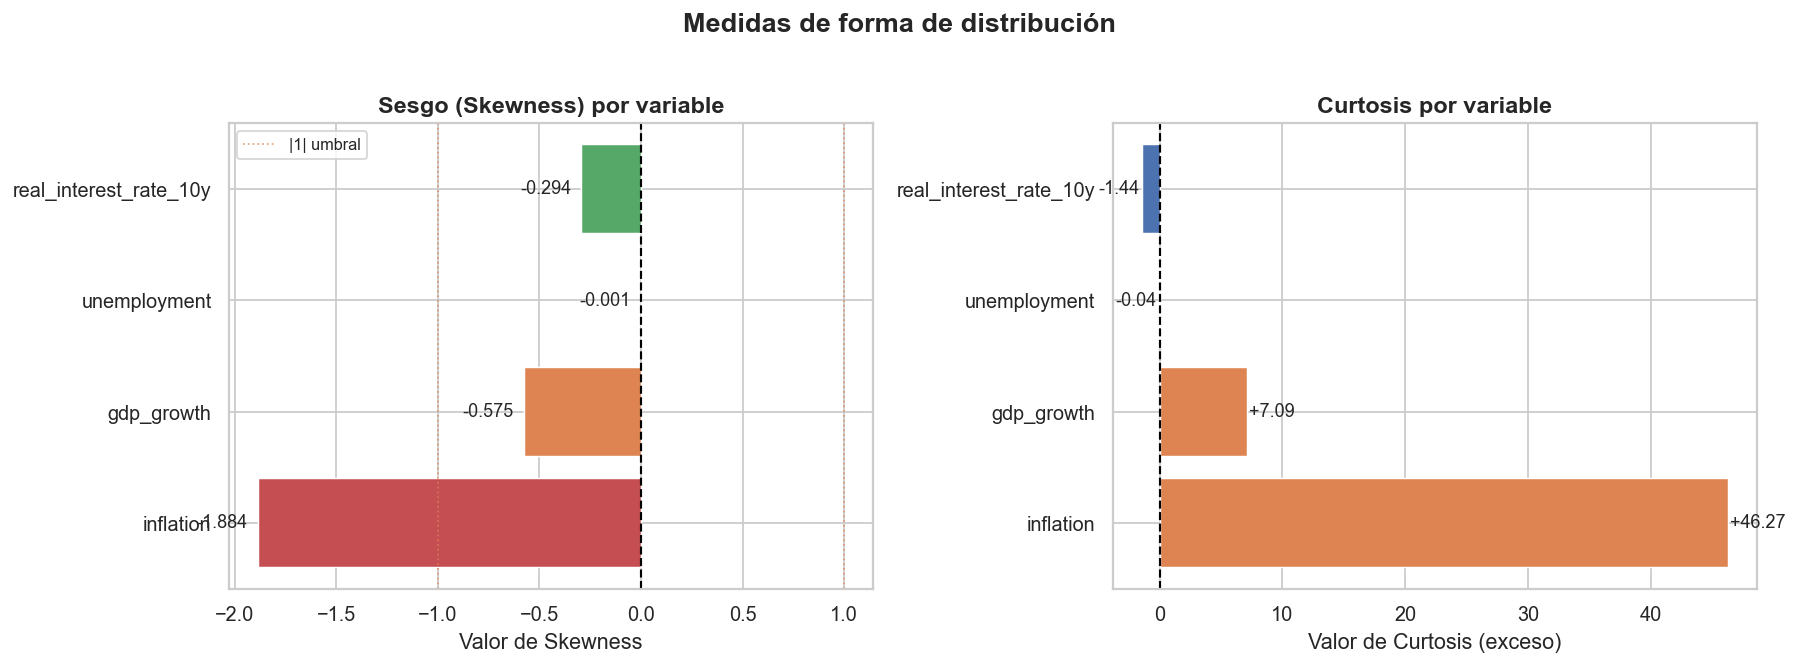

In [31]:
# ── Gráfico de barras: Skewness ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skewness
colors_skew = [PALETTE_WARN if abs(v) > 1 else (PALETTE_PALETTE := '#C44E52' if abs(v) > 2 else PALETTE_OK) for v in skew_vals]
colors_skew = [PALETTE_WARN if 0.5 < abs(v) <= 1 else ('#C44E52' if abs(v) > 1 else PALETTE_OK) for v in skew_vals]

bars = axes[0].barh(skew_vals.index, skew_vals.values, color=colors_skew, edgecolor='white', linewidth=0.8)
axes[0].axvline(0, color='black', lw=1.2, ls='--')
axes[0].axvline( 1, color=PALETTE_WARN, lw=1, ls=':', alpha=0.7, label='|1| umbral')
axes[0].axvline(-1, color=PALETTE_WARN, lw=1, ls=':', alpha=0.7)
for bar, val in zip(bars, skew_vals.values):
    axes[0].text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
axes[0].set_title('Sesgo (Skewness) por variable', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Valor de Skewness')
axes[0].legend(fontsize=9)

# Curtosis
colors_kurt = [PALETTE_WARN if abs(v) > 3 else PALETTE_NUM for v in kurt_vals]
bars2 = axes[1].barh(kurt_vals.index, kurt_vals.values, color=colors_kurt, edgecolor='white', linewidth=0.8)
axes[1].axvline(0, color='black', lw=1.2, ls='--')
for bar, val in zip(bars2, kurt_vals.values):
    axes[1].text(val + (0.2 if val >= 0 else -0.2), bar.get_y() + bar.get_height()/2,
                 f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
axes[1].set_title('Curtosis por variable', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valor de Curtosis (exceso)')

plt.suptitle('Medidas de forma de distribución', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

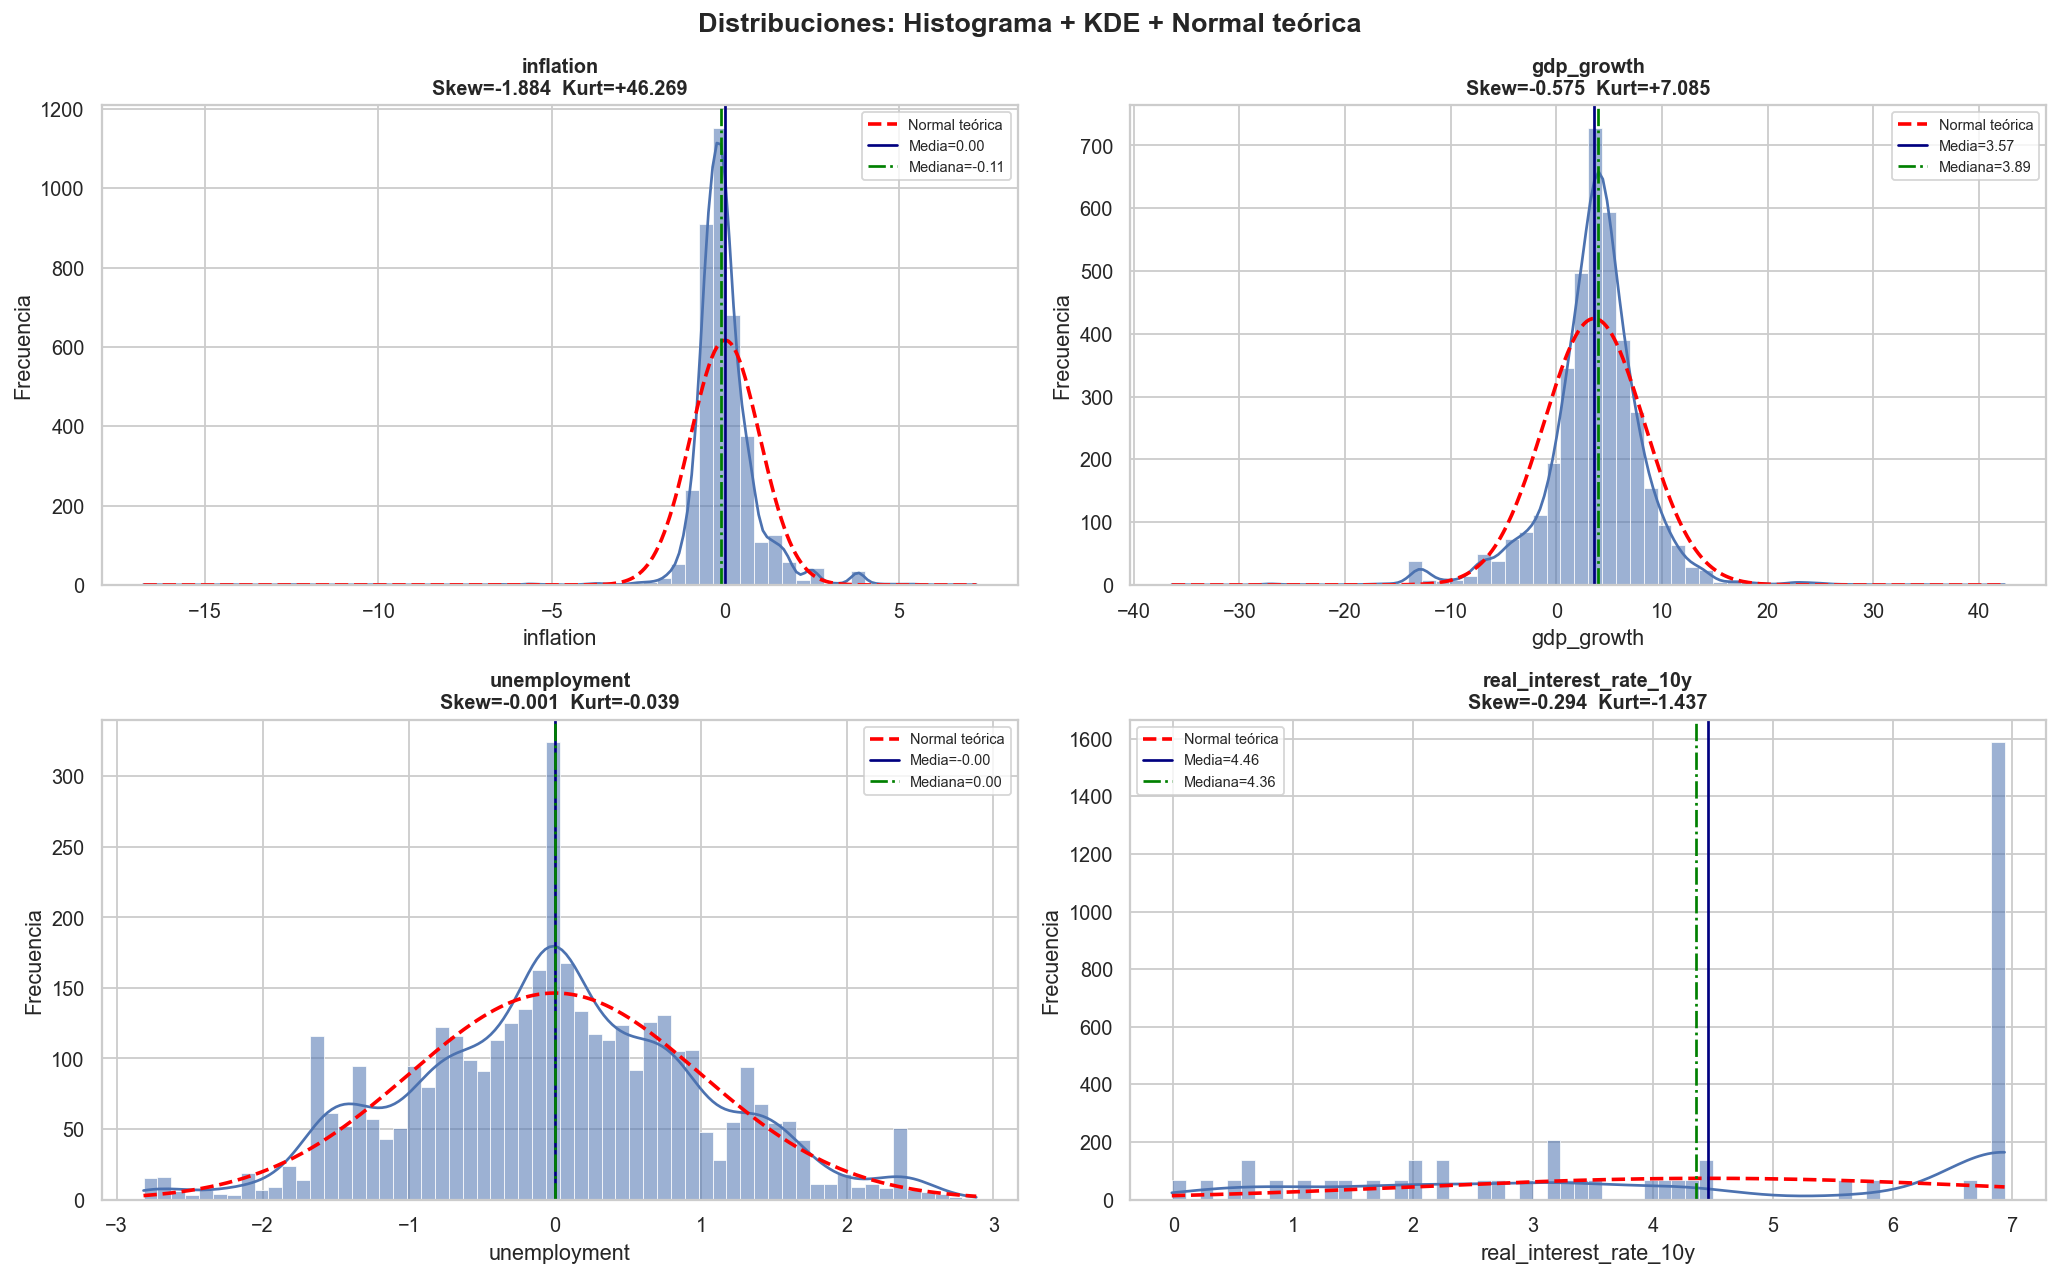

In [32]:
# ── Histogramas + curva KDE + distribución normal teórica ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    data = df[col].dropna()
    ax   = axes[i]

    # Histograma + KDE
    sns.histplot(data, bins=60, kde=True, ax=ax, color=PALETTE_NUM,
                 alpha=0.55, edgecolor='white', linewidth=0.4)

    # Normal teórica
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    normal_y = stats.norm.pdf(x, mu, sigma)
    # Escalar normal_y a la escala del histograma
    bin_width = (data.max() - data.min()) / 60
    normal_y_scaled = normal_y * len(data) * bin_width
    ax.plot(x, normal_y_scaled, color='red', lw=2, ls='--', label='Normal teórica')

    # Líneas de media y mediana
    ax.axvline(mu, color='navy', lw=1.5, ls='-', label=f'Media={mu:.2f}')
    ax.axvline(data.median(), color='green', lw=1.5, ls='-.', label=f'Mediana={data.median():.2f}')

    skew_v = data.skew()
    kurt_v = data.kurt()
    ax.set_title(f'{col}\nSkew={skew_v:+.3f}  Kurt={kurt_v:+.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones: Histograma + KDE + Normal teórica', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

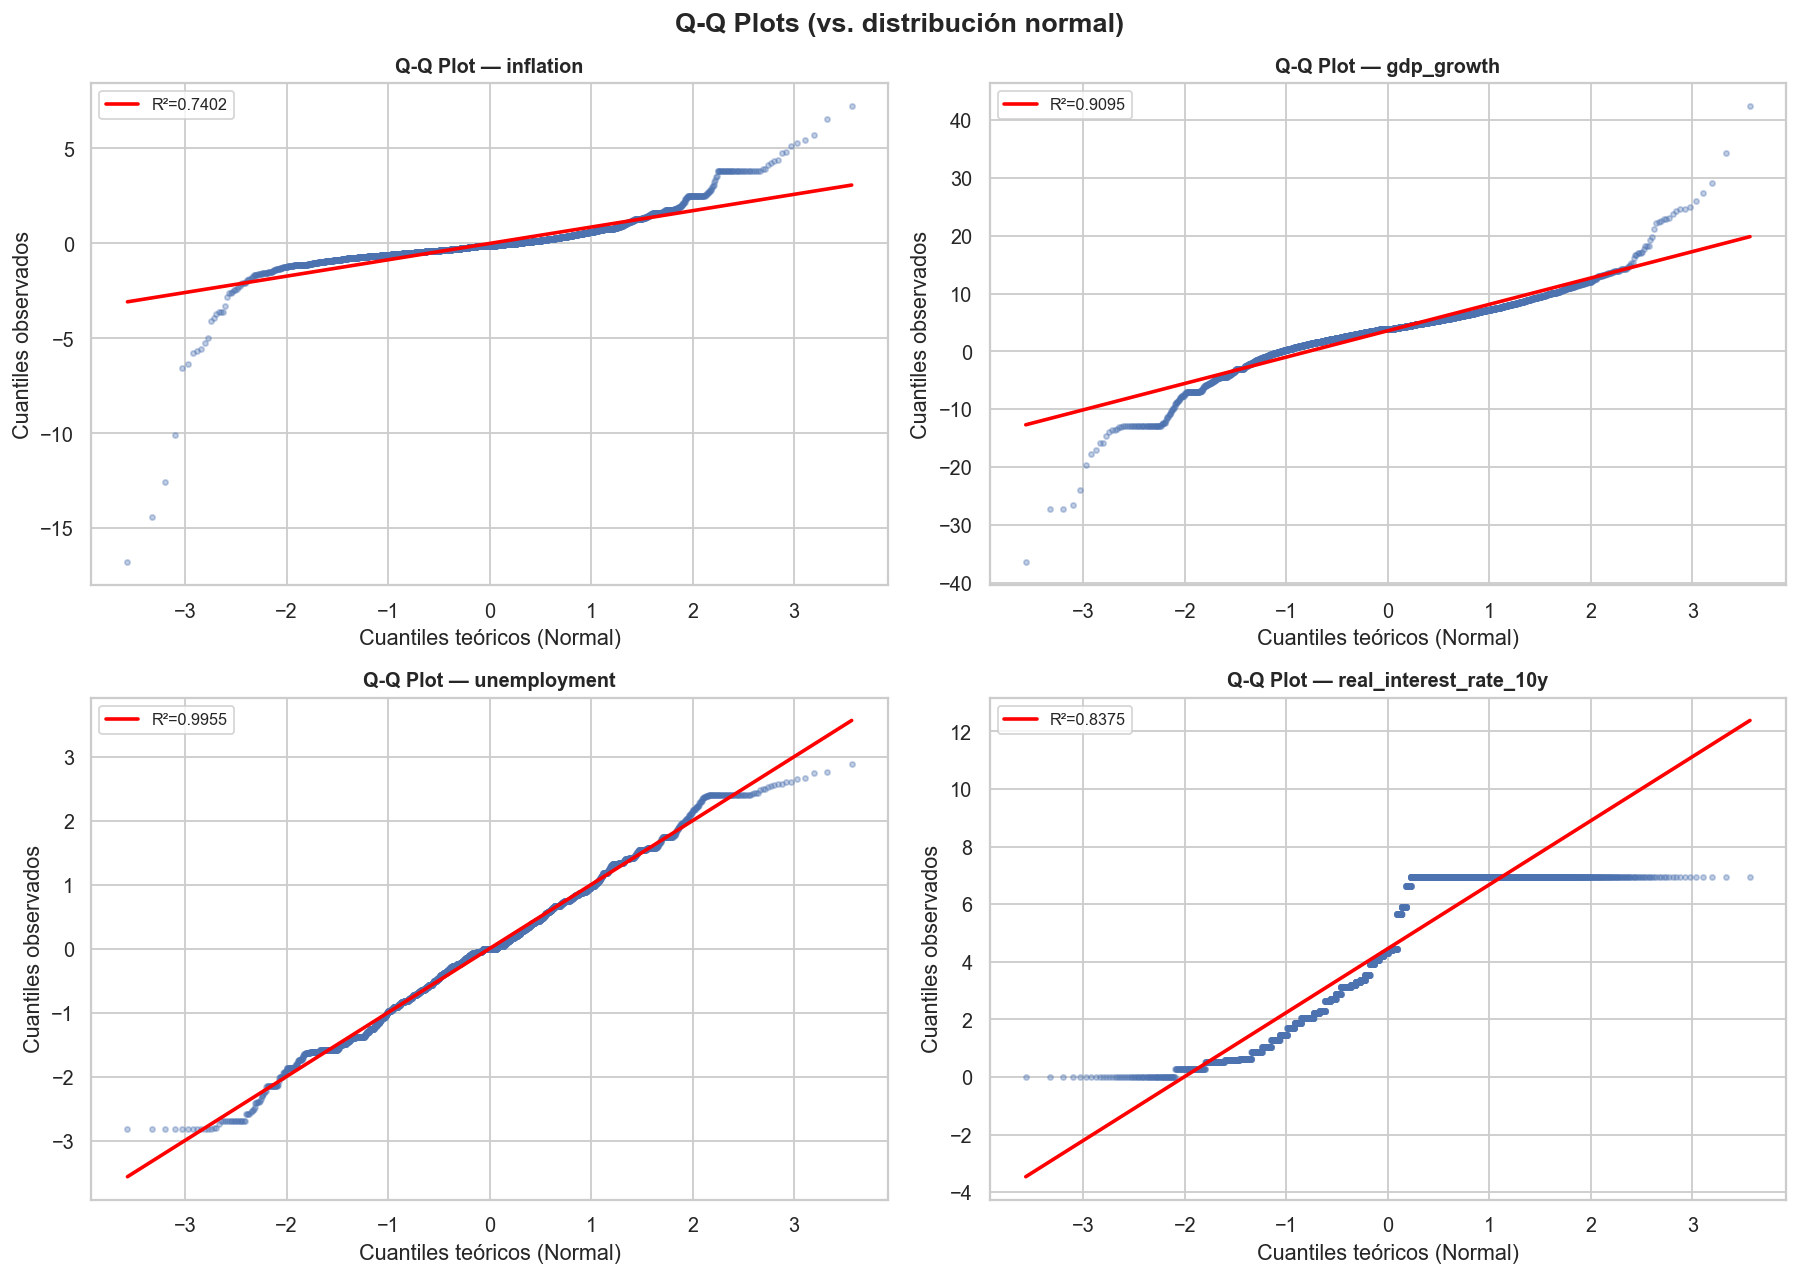

In [33]:
# ── Q-Q Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    data = df[col].dropna()
    ax = axes[i]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=PALETTE_NUM, alpha=0.35, s=8, rasterized=True)
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept, color='red', lw=2, label=f'R²={r**2:.4f}')
    ax.set_title(f'Q-Q Plot — {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos (Normal)')
    ax.set_ylabel('Cuantiles observados')
    ax.legend(fontsize=9)

plt.suptitle('Q-Q Plots (vs. distribución normal)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Boxplots

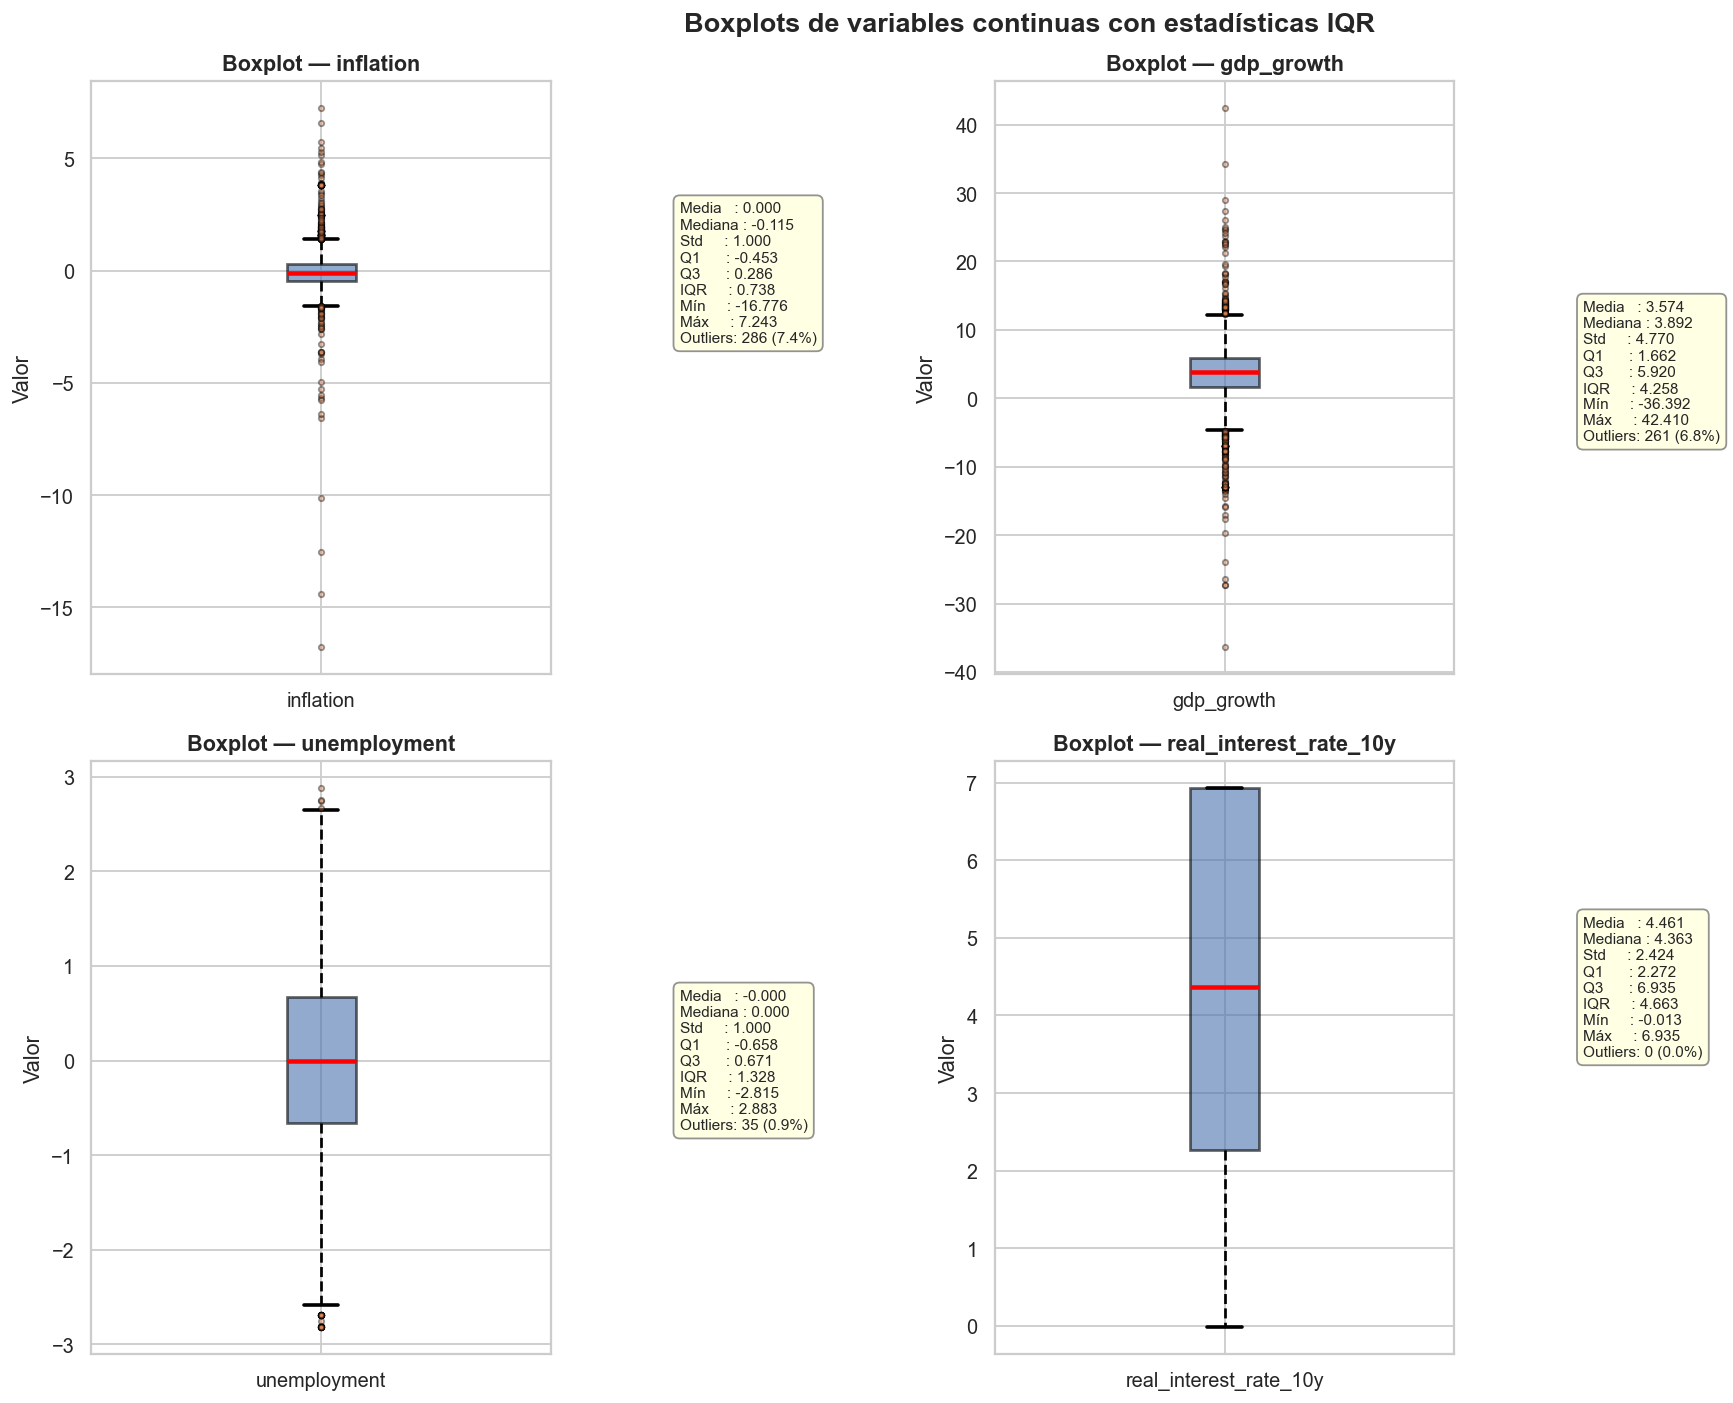

In [34]:
# ── Boxplots individuales con estadísticas anotadas ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    data = df[col].dropna()
    ax   = axes[i]

    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE_NUM, alpha=0.6, linewidth=1.5),
                    medianprops=dict(color='red', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5, linestyle='--'),
                    capprops=dict(linewidth=2),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor=PALETTE_WARN, alpha=0.4))

    # Calcular IQR
    Q1, Q3  = data.quantile(0.25), data.quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    n_out   = ((data < lower) | (data > upper)).sum()
    pct_out = n_out / len(data) * 100

    # Anotar estadísticas
    stats_text = (
        f'Media   : {data.mean():.3f}\n'
        f'Mediana : {data.median():.3f}\n'
        f'Std     : {data.std():.3f}\n'
        f'Q1      : {Q1:.3f}\n'
        f'Q3      : {Q3:.3f}\n'
        f'IQR     : {IQR:.3f}\n'
        f'Mín     : {data.min():.3f}\n'
        f'Máx     : {data.max():.3f}\n'
        f'Outliers: {n_out} ({pct_out:.1f}%)'
    )
    ax.text(1.28, data.median(), stats_text,
            va='center', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.85),
            transform=ax.get_yaxis_transform())

    ax.set_title(f'Boxplot — {col}', fontsize=12, fontweight='bold')
    ax.set_xticklabels([col])
    ax.set_ylabel('Valor')

plt.suptitle('Boxplots de variables continuas con estadísticas IQR', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

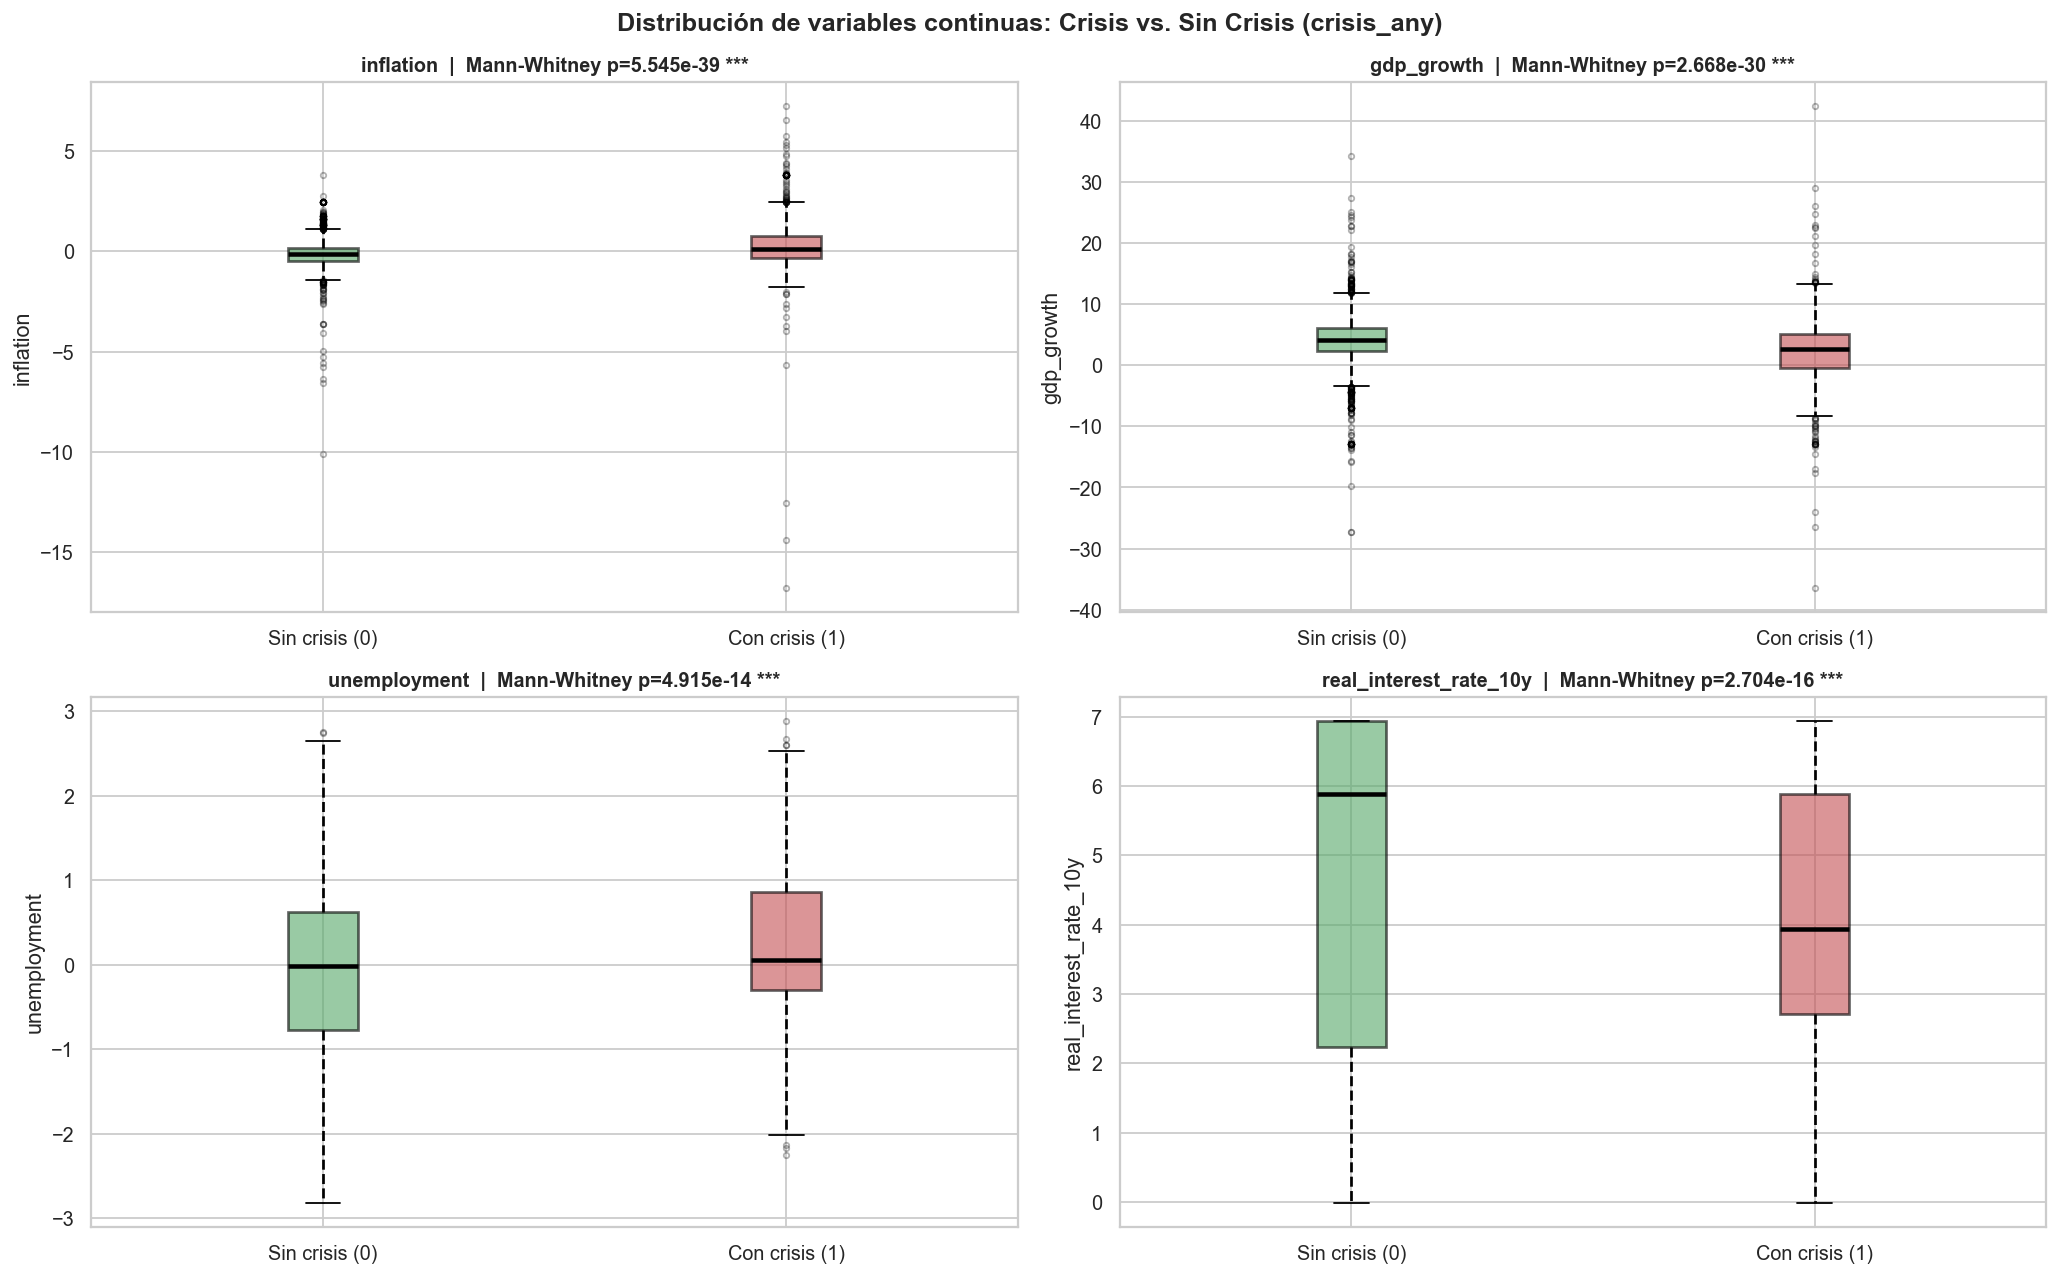

In [35]:
# ── Boxplots comparativos: variable continua segmentada por crisis_any ────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

labels_map = {0: 'Sin crisis', 1: 'Con crisis'}
colors_map = {0: PALETTE_OK, 1: '#C44E52'}

for i, col in enumerate(CONTINUOUS_COLS):
    ax = axes[i]
    groups = [df.loc[df['crisis_any'] == g, col].dropna().values for g in [0, 1]]
    bp = ax.boxplot(groups, patch_artist=True,
                    labels=['Sin crisis (0)', 'Con crisis (1)'],
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(linewidth=2.5, color='black'),
                    whiskerprops=dict(linewidth=1.5, linestyle='--'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    for patch, color in zip(bp['boxes'], [PALETTE_OK, '#C44E52']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Test Mann-Whitney U
    stat_mw, p_mw = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))
    ax.set_title(f'{col}  |  Mann-Whitney p={p_mw:.3e} {sig}', fontsize=11, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Distribución de variables continuas: Crisis vs. Sin Crisis (crisis_any)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

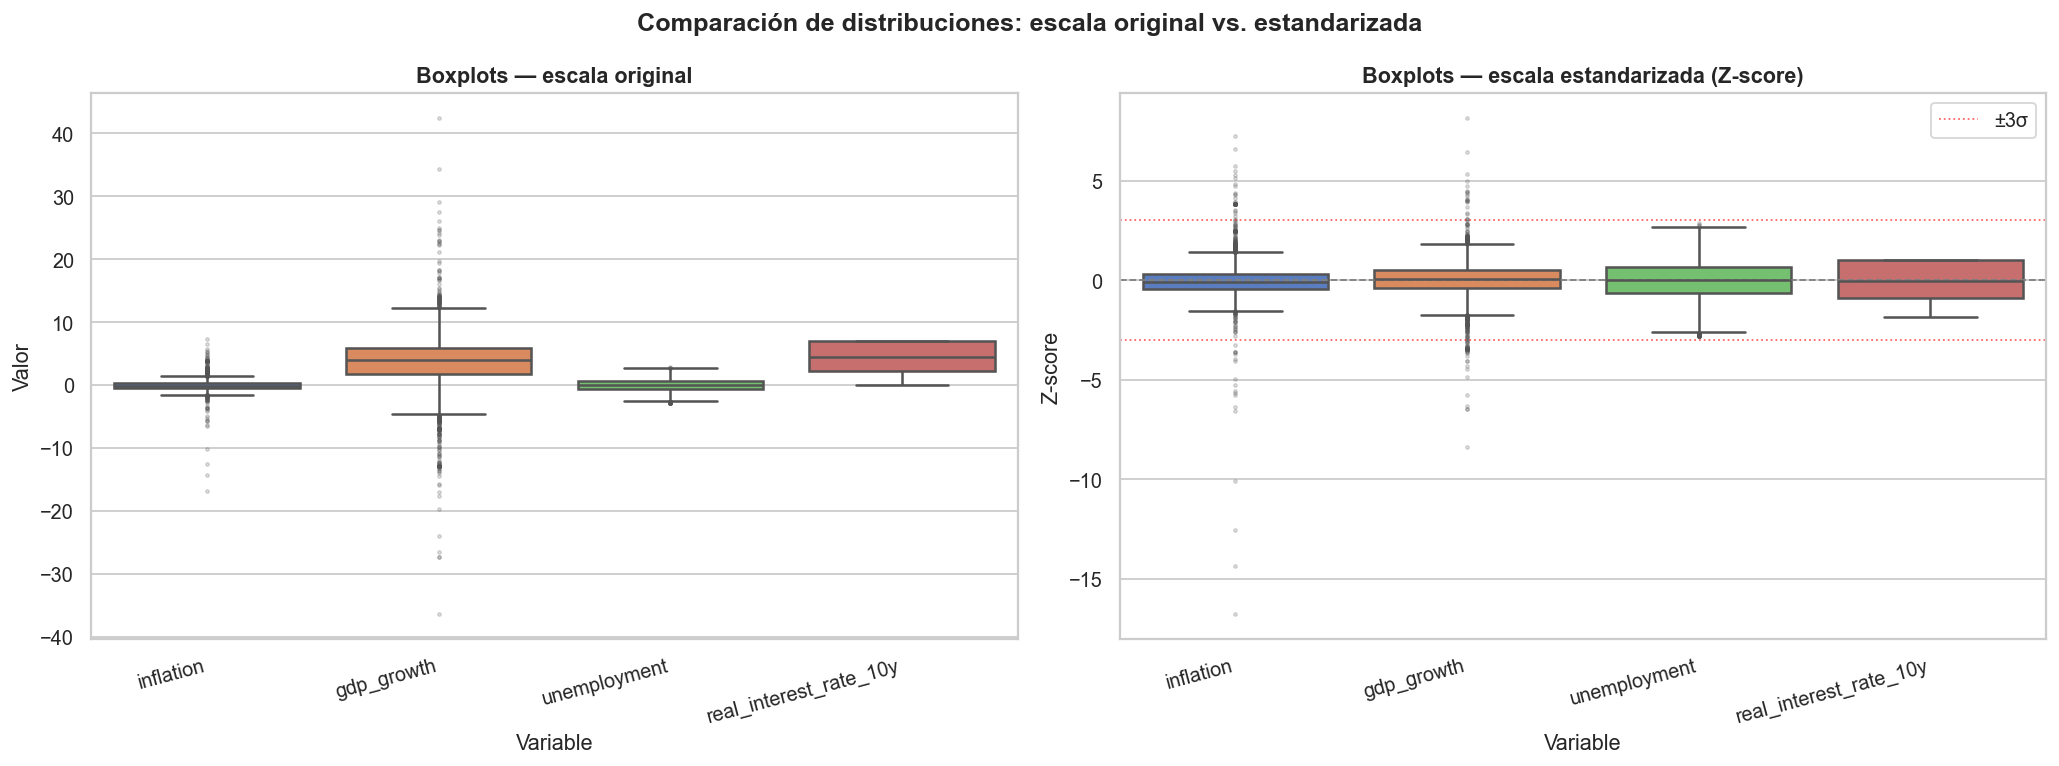

In [36]:
# ── Boxplot conjunto (normalizado) ────────────────────────────────────────────
df_melt = df[CONTINUOUS_COLS].melt(var_name='Variable', value_name='Valor')

# Normalizar para comparación visual
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df[CONTINUOUS_COLS].dropna()),
    columns=CONTINUOUS_COLS
).melt(var_name='Variable', value_name='Z-score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sin normalizar
sns.boxplot(data=df_melt, x='Variable', y='Valor', ax=axes[0],
            palette='muted', linewidth=1.4, flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[0].set_title('Boxplots — escala original', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Normalizado (Z-score)
sns.boxplot(data=df_norm, x='Variable', y='Z-score', ax=axes[1],
            palette='muted', linewidth=1.4, flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[1].axhline(0, color='gray', lw=1, ls='--')
axes[1].axhline( 3, color='red', lw=1, ls=':', alpha=0.6, label='±3σ')
axes[1].axhline(-3, color='red', lw=1, ls=':', alpha=0.6)
axes[1].set_title('Boxplots — escala estandarizada (Z-score)', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend()

plt.suptitle('Comparación de distribuciones: escala original vs. estandarizada',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Distribución de variables binarias

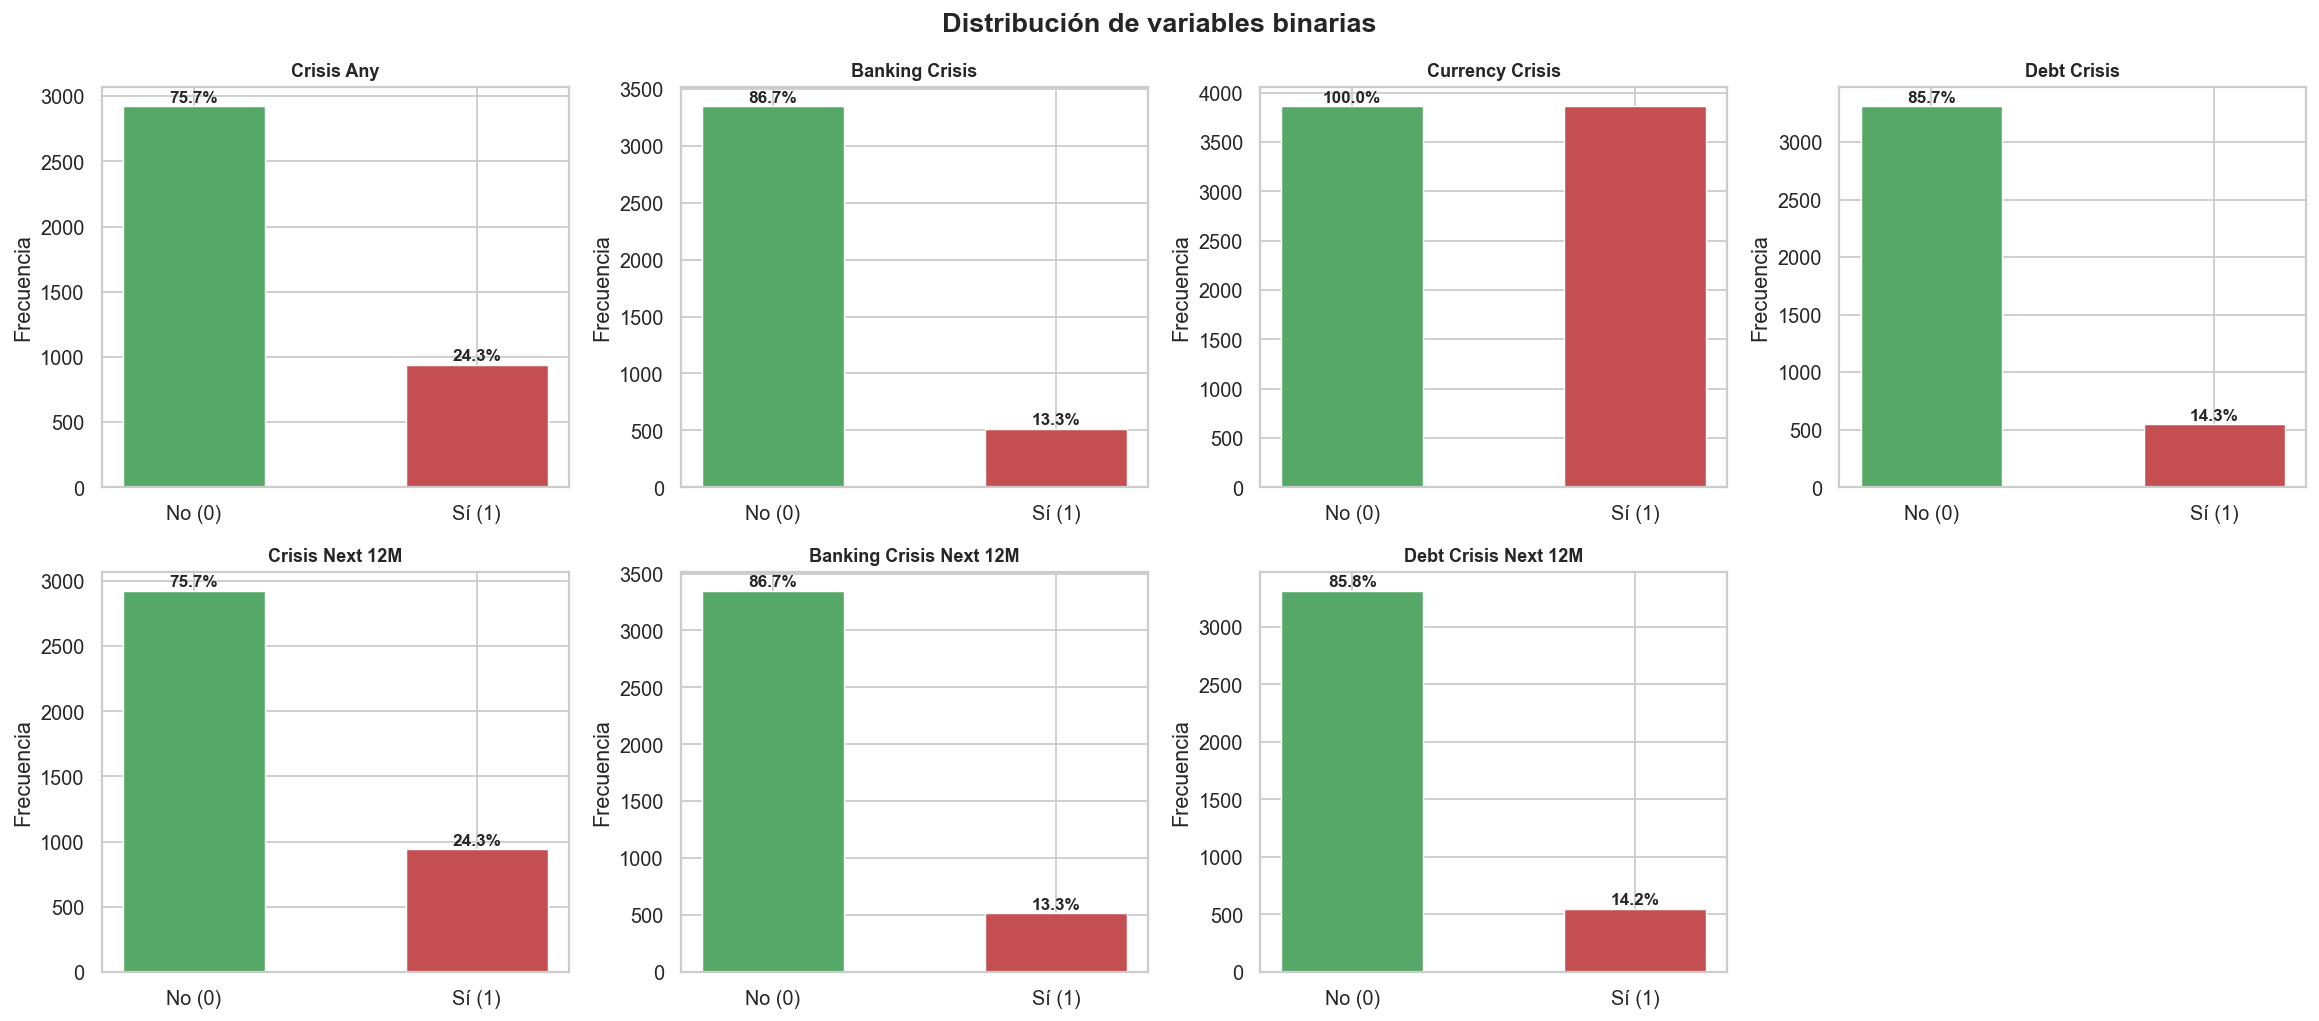

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(BINARY_COLS):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    pct    = df[col].value_counts(normalize=True).sort_index() * 100
    bars = ax.bar([0, 1], counts.values,
                  color=[PALETTE_OK, '#C44E52'], edgecolor='white', linewidth=0.8,
                  width=0.5)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{p:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No (0)', 'Sí (1)'])
    ax.set_ylabel('Frecuencia')

# Ocultar eje extra
axes[-1].set_visible(False)

plt.suptitle('Distribución de variables binarias', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Matriz de correlaciones

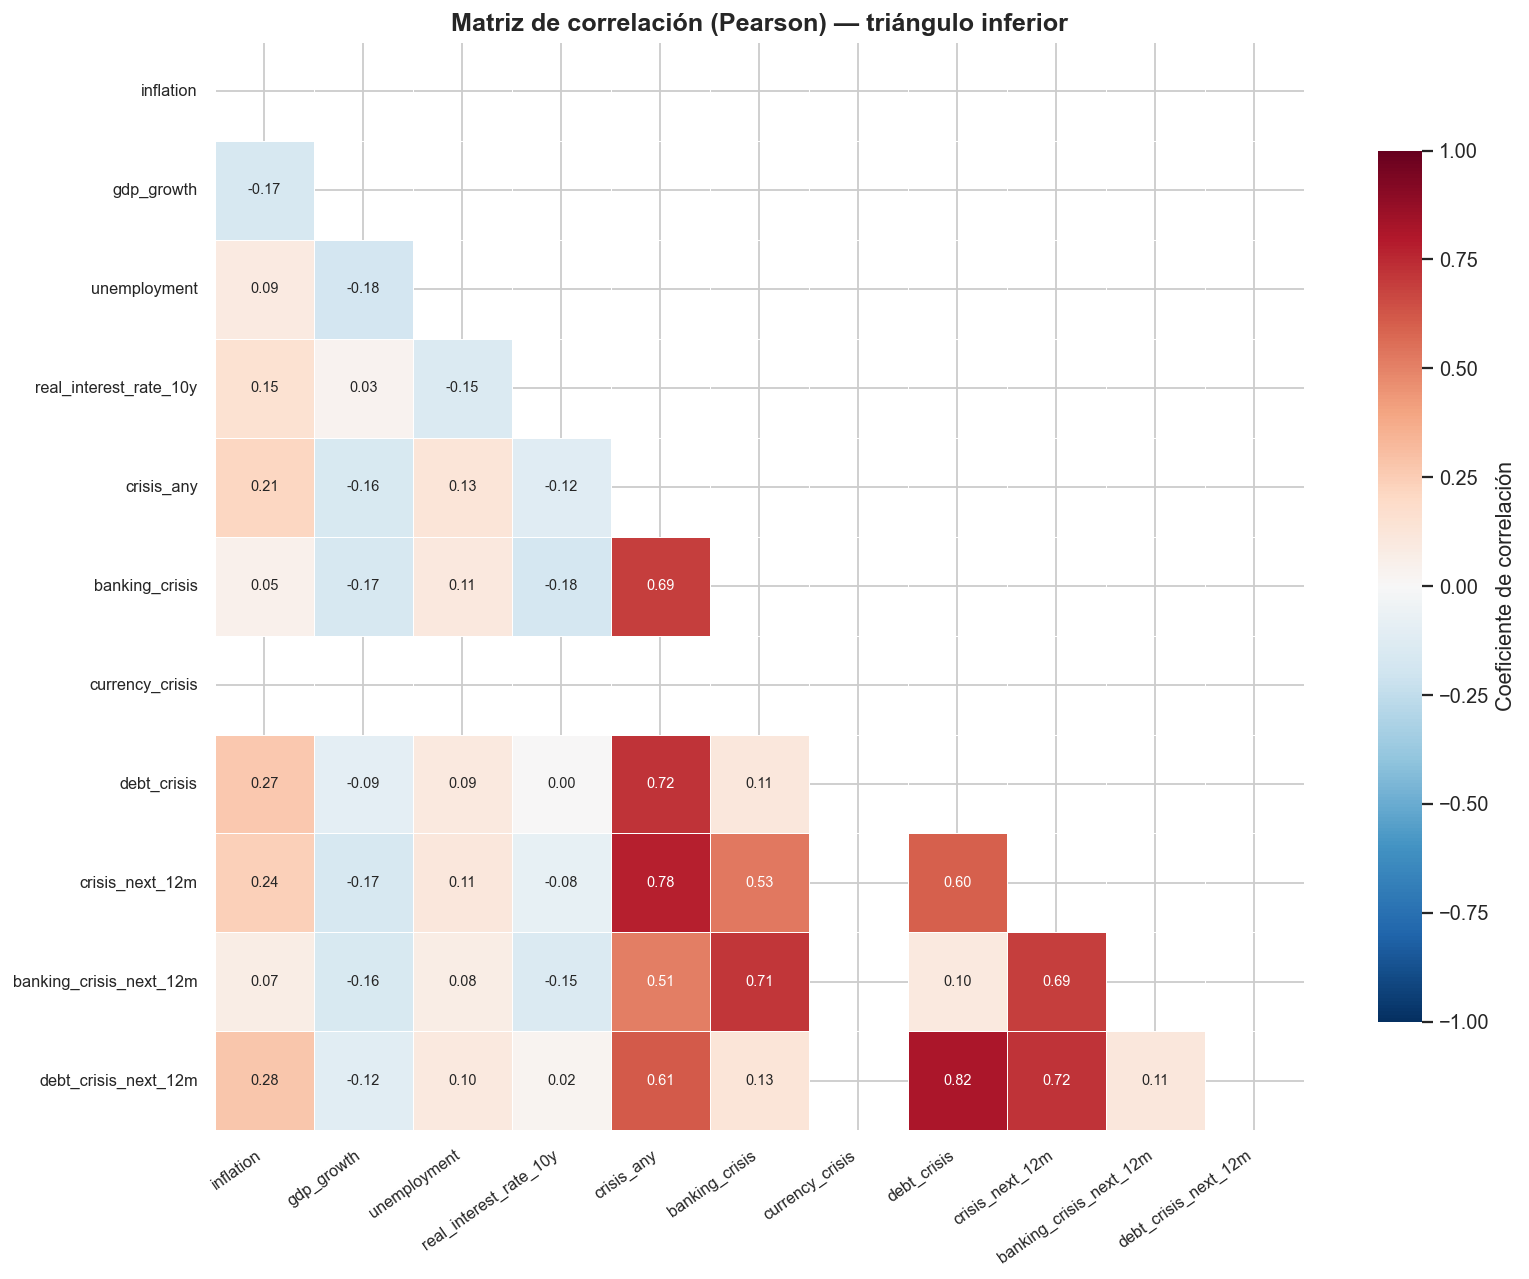

In [38]:
ALL_NUM_COLS = CONTINUOUS_COLS + BINARY_COLS
corr = df[ALL_NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # triángulo superior

sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'},
    ax=ax
)
plt.title('Matriz de correlación (Pearson) — triángulo inferior', fontsize=14, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [39]:
# Pares con correlación > |0.3|
corr_flat = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool)).stack()
corr_flat.name = 'correlacion'
significant = corr_flat[corr_flat.abs() > 0.3].sort_values(key=abs, ascending=False)

print('=== Correlaciones significativas (|r| > 0.30) ===')
display(significant.reset_index().rename(columns={'level_0': 'Variable_A', 'level_1': 'Variable_B'}))

=== Correlaciones significativas (|r| > 0.30) ===


,Variable_A,Variable_B,correlacion
0,debt_crisis_next_12m,debt_crisis,0.818884
1,crisis_next_12m,crisis_any,0.777096
2,debt_crisis,crisis_any,0.719267
3,debt_crisis_next_12m,crisis_next_12m,0.719010
4,banking_crisis_next_12m,banking_crisis,0.713236
5,banking_crisis_next_12m,crisis_next_12m,0.692112
6,banking_crisis,crisis_any,0.691625
7,debt_crisis_next_12m,crisis_any,0.611472
8,crisis_next_12m,debt_crisis,0.600702
9,crisis_next_12m,banking_crisis,0.527006


---
## 7. Detección de Outliers por IQR

In [40]:
print('=== Resumen de outliers (regla IQR × 1.5) ===')
outlier_summary = []
for col in CONTINUOUS_COLS:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    mask_out = (data < lower) | (data > upper)
    n_out  = mask_out.sum()
    outlier_summary.append({
        'Variable'   : col,
        'Límite Inf' : round(lower, 4),
        'Límite Sup' : round(upper, 4),
        'N Outliers' : n_out,
        '% Outliers' : round(n_out / len(data) * 100, 2),
        'Min outlier': round(data[mask_out].min(), 4) if n_out > 0 else np.nan,
        'Max outlier': round(data[mask_out].max(), 4) if n_out > 0 else np.nan,
    })

out_df = pd.DataFrame(outlier_summary)
display(out_df.style
    .background_gradient(subset=['% Outliers'], cmap='Reds')
    .format({'% Outliers': '{:.2f}%'})
)

=== Resumen de outliers (regla IQR × 1.5) ===


,Variable,Límite Inf,Límite Sup,N Outliers,% Outliers,Min outlier,Max outlier
0,inflation,-1.559900,1.392900,286,7.40%,-16.775600,7.242600
1,gdp_growth,-4.724200,12.305900,261,6.75%,-36.392000,42.410400
2,unemployment,-2.649800,2.662900,35,0.91%,-2.815200,2.883400
3,real_interest_rate_10y,-4.721900,13.928600,0,0.00%,nan,nan


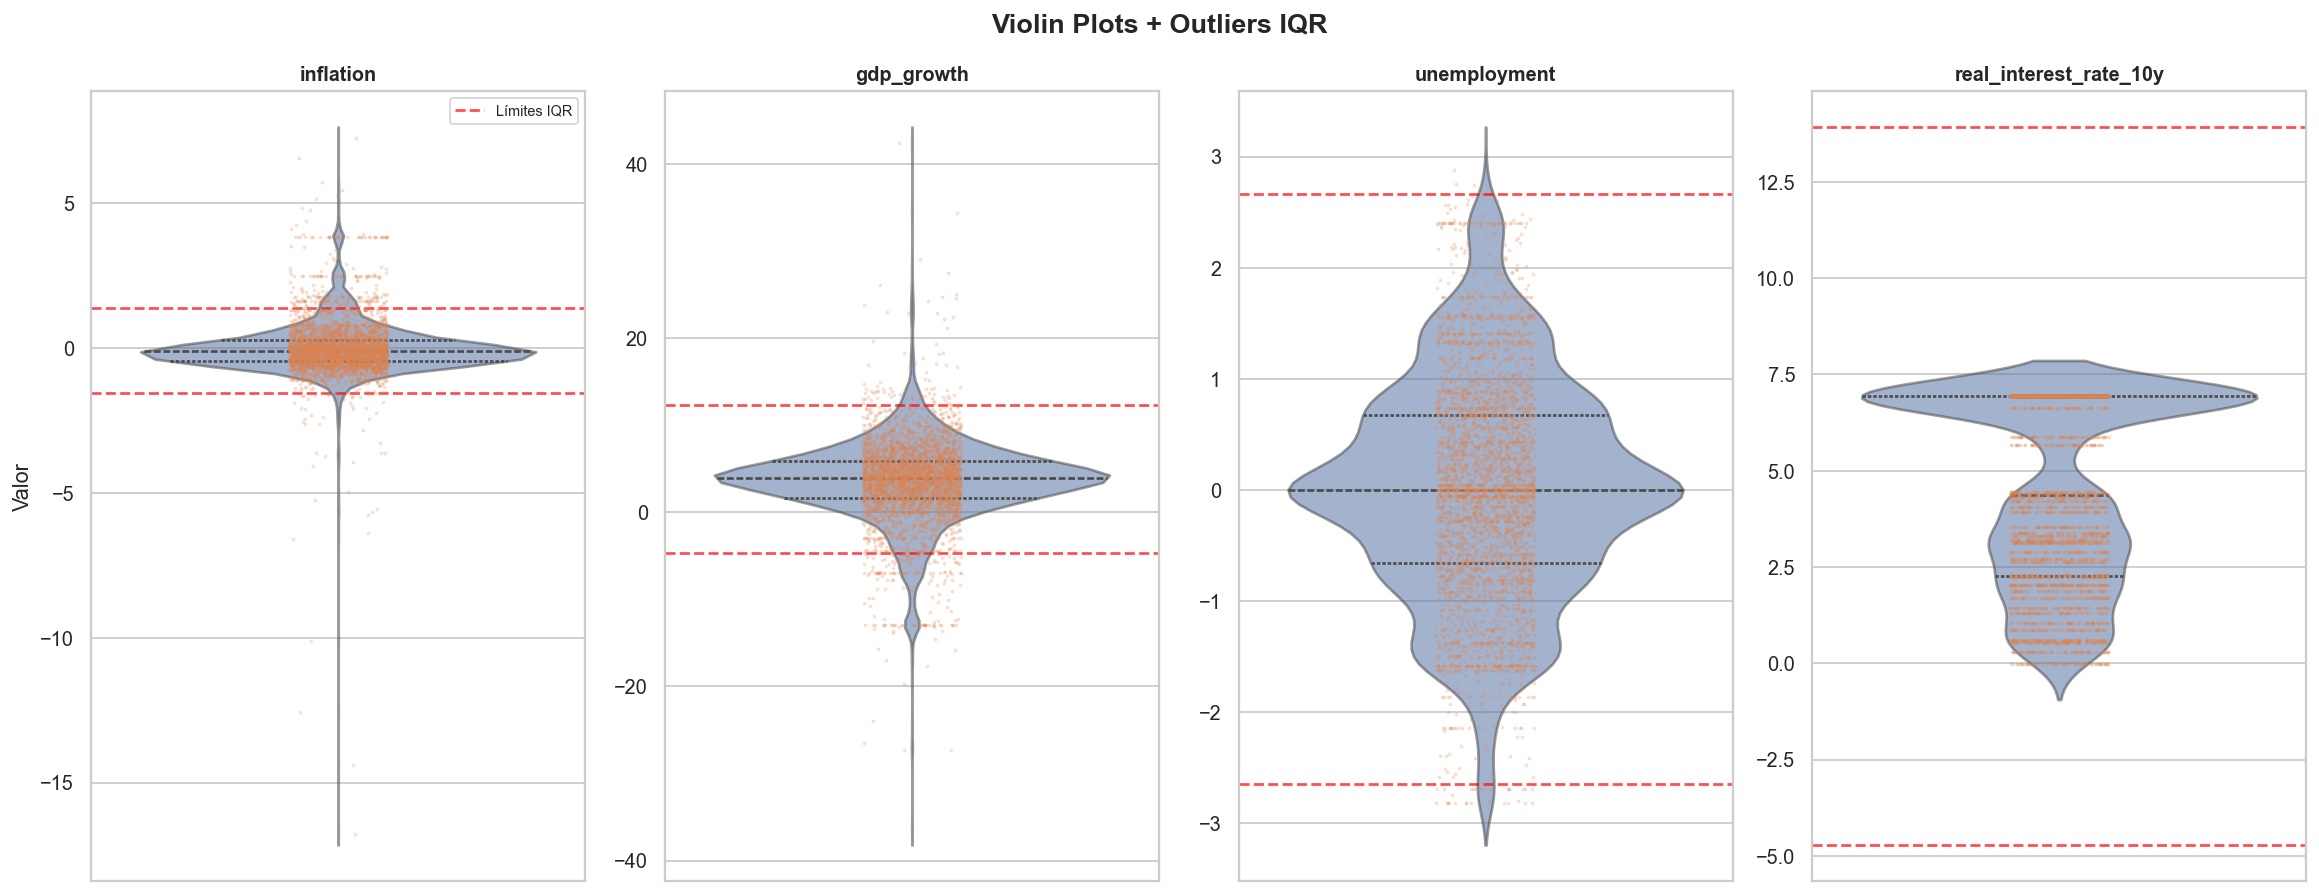

In [41]:
# ── Violin plot + Strip para ver outliers en contexto ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 7))

for i, col in enumerate(CONTINUOUS_COLS):
    ax = axes[i]
    sns.violinplot(y=df[col], ax=ax, color=PALETTE_NUM, alpha=0.55, inner='quartile', linewidth=1.5)
    # Overlapping stripplot para ver puntos individuales extremos
    sns.stripplot(y=df[col], ax=ax, color=PALETTE_WARN, size=2, alpha=0.25, jitter=True)

    # Líneas IQR
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    ax.axhline(Q1 - 1.5 * IQR, color='red', lw=1.5, ls='--', alpha=0.7, label='Límites IQR')
    ax.axhline(Q3 + 1.5 * IQR, color='red', lw=1.5, ls='--', alpha=0.7)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor' if i == 0 else '')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Violin Plots + Outliers IQR', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Tendencia temporal

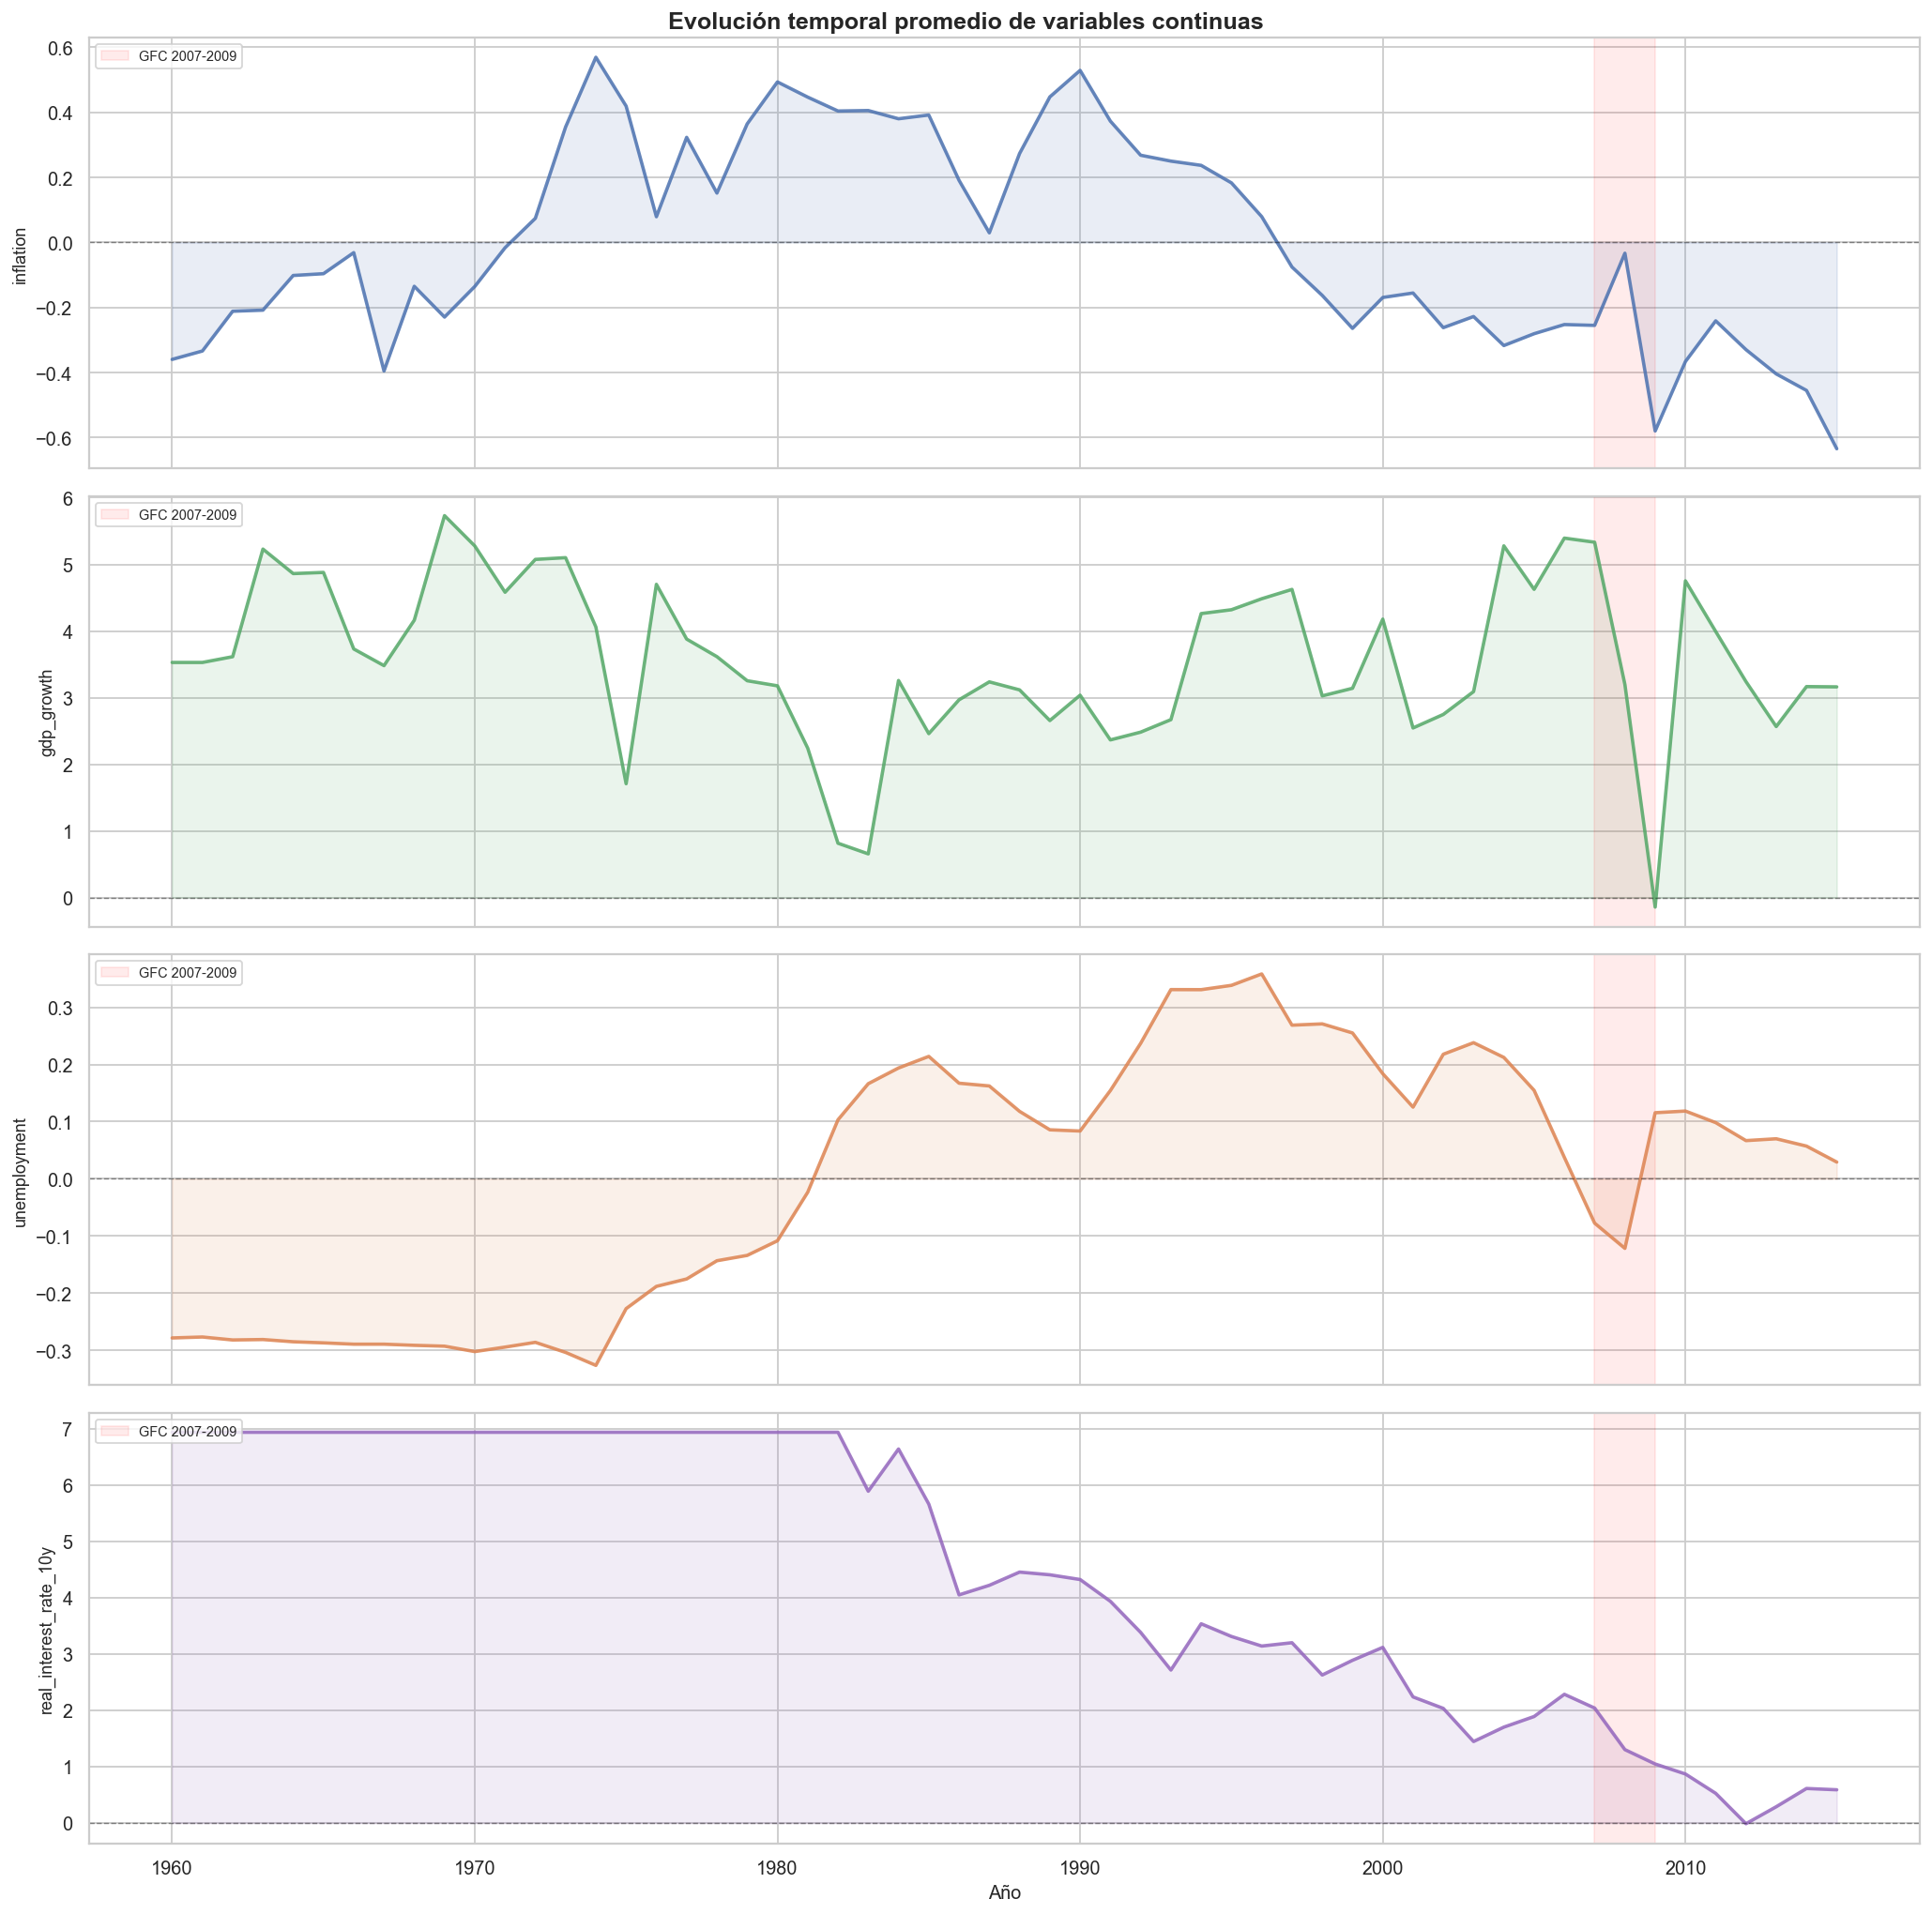

In [42]:
# Evolución anual promedio de las variables continuas
yearly = df.groupby('year')[CONTINUOUS_COLS].mean()

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

colors_trend = [PALETTE_NUM, PALETTE_OK, PALETTE_WARN, '#9467BD']

for i, (col, color) in enumerate(zip(CONTINUOUS_COLS, colors_trend)):
    ax = axes[i]
    ax.plot(yearly.index, yearly[col], color=color, lw=2, alpha=0.85)
    ax.fill_between(yearly.index, yearly[col], alpha=0.12, color=color)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)

    # Sombra crisis financiera global
    ax.axvspan(2007, 2009, alpha=0.08, color='red', label='GFC 2007-2009')

    ax.set_ylabel(col, fontsize=10)
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Año', fontsize=11)
plt.suptitle('Evolución temporal promedio de variables continuas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Resumen final

In [43]:
print('=' * 70)
print('RESUMEN ESTADÍSTICO FINAL — global_crisis_data_cleaned.csv')
print('=' * 70)
print(f'  Observaciones : {len(df):,}')
print(f'  Países únicos : {df["iso3"].nunique()}')
print(f'  Rango temporal: {int(df["year"].min())} – {int(df["year"].max())}')
print()
print('-' * 70)
print('SESGO (Skewness) — Interpretación:')
for col in CONTINUOUS_COLS:
    s = df[col].skew()
    direction  = 'cola derecha larga (+)' if s > 0 else 'cola izquierda larga (-)'
    severity   = '⚠ ALTO' if abs(s) > 1 else ('◑ moderado' if abs(s) > 0.5 else '✔ simétrico')
    print(f'  {col:<30} {s:+.4f}  {severity}  → {direction}')
print()
print('-' * 70)
print('OUTLIERS (IQR × 1.5):')
for _, row in out_df.iterrows():
    print(f'  {row["Variable"]:<30} {row["N Outliers"]:>5} outliers ({row["% Outliers"]:>5.2f}%)')
print()
print('-' * 70)
print('PREVALENCIA DE CRISIS (% de filas con valor = 1):')
for col in BINARY_COLS:
    pct = df[col].mean() * 100
    print(f'  {col:<35} {pct:>6.2f}%')
print('=' * 70)

RESUMEN ESTADÍSTICO FINAL — global_crisis_data_cleaned.csv
  Observaciones : 3,864
  Países únicos : 69
  Rango temporal: 1960 – 2015

----------------------------------------------------------------------
SESGO (Skewness) — Interpretación:
  inflation                      -1.8841  ⚠ ALTO  → cola izquierda larga (-)
  gdp_growth                     -0.5754  ◑ moderado  → cola izquierda larga (-)
  unemployment                   -0.0009  ✔ simétrico  → cola izquierda larga (-)
  real_interest_rate_10y         -0.2939  ✔ simétrico  → cola izquierda larga (-)

----------------------------------------------------------------------
OUTLIERS (IQR × 1.5):
  inflation                        286 outliers ( 7.40%)
  gdp_growth                       261 outliers ( 6.75%)
  unemployment                      35 outliers ( 0.91%)
  real_interest_rate_10y             0 outliers ( 0.00%)

----------------------------------------------------------------------
PREVALENCIA DE CRISIS (% de filas con valor